# Four-target shortest paths: sorted conditioning, 50 vs 200 epochs

**Question.** Does a longer training budget improve task completion for the coordinate-sorted conditional SFP model?

- Load the existing 10,000 training and 1,000 validation layouts; do not load the test split.
- Keep the four-layer, 128-unit SiLU MLP, sampling seeds, batch size and steps per epoch fixed.
- Train from scratch for 200 epochs with a 200-epoch cosine schedule. This compares **budgets and associated schedules**, not an extra 150 epochs of the old run.
- Choose checkpoints using 20,000 fixed probes from independent validation layouts.
- Compare the same 100 training and 100 validation layouts, starting exactly at the task start, with 1,000 RK4 steps and a 0.02 visit tolerance.

**Interpretation.** Approximate target visits are the primary diagnostic. A shorter path that misses targets is not a better solution. No exact optimality claim is made from tolerance-based visits. The path parameter is normalized arc length, not physical time.

**Usage:** Run top to bottom. Change `PROJECT_ROOT` if needed. Completed epochs resume automatically; a completed run skips training. No old notebook variables are required. Numerical training/evaluation must run on your machine with the saved dataset and 50-epoch checkpoint.


In [1]:
from pathlib import Path
import copy
import hashlib
import itertools
import json
import random
import sys
import platform
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import display, Markdown

PROJECT_ROOT = Path("/home/matcho/projects/streaming-flow-policy")
TASK_ROOT = PROJECT_ROOT / "experiments/four_boxes_experiments/four_targets"
DATASET_DIR = TASK_ROOT / "datasets/v1"
BASELINE_DIR = TASK_ROOT / "runs/conditional_mlp_canonical_v1_seed0"
RUN_DIR = TASK_ROOT / "runs/conditional_mlp_canonical_200epochs_v1_seed0"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

required = [DATASET_DIR / "config.json", DATASET_DIR / "train.npz",
            DATASET_DIR / "validation.npz", BASELINE_DIR / "best.pt",
            BASELINE_DIR / "config.json"]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Required existing files are missing:\n" + "\n".join(missing))

splits = {}
for name in ["train", "validation"]:
    with np.load(DATASET_DIR / f"{name}.npz", allow_pickle=False) as archive:
        splits[name] = {key: archive[key].copy() for key in archive.files}
    split = splits[name]
    n = len(split["targets"])
    for key, shape in {"starts": (n, 2), "targets": (n, 4, 2),
                       "conditions": (n, 10), "routes": (n, 5, 2),
                       "knot_tau": (n, 5), "lengths": (n,)}.items():
        assert split[key].shape == shape, (name, key, split[key].shape)
        assert np.isfinite(split[key]).all(), (name, key)
    assert np.all(np.diff(split["knot_tau"], axis=1) > 0)
    np.testing.assert_allclose(split["knot_tau"][:, 0], 0)
    np.testing.assert_allclose(split["knot_tau"][:, -1], 1)
    np.testing.assert_array_equal(split["conditions"], np.concatenate(
        [split["starts"], split["targets"].reshape(n, 8)], axis=1))
    np.testing.assert_array_equal(split["routes"][:, 0], split["starts"])
assert len(splits["train"]["targets"]) == 10_000
assert len(splits["validation"]["targets"]) == 1_000

def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

CONFIG = {
    "experiment": "full_dataset_canonical_budget_200",
    "dataset_dir": str(DATASET_DIR),
    "input_preprocessing": "sort_targets_by_x_then_y",
    "num_training_layouts": 10_000,
    "training_seed": 0, "train_sampling_seed": 1000,
    "validation_probe_seed": 500, "validation_probe_size": 20_000,
    "num_epochs": 200, "steps_per_epoch": 100, "batch_size": 2048,
    "learning_rate": 1e-3, "weight_decay": 1e-6,
    "hidden_dim": 128, "num_hidden_layers": 4,
    "sigma_0": 0.05, "stabilizing_gain": 2.5,
    "dataset_sha256": {p.name: sha256(p) for p in required[:3]},
}
BASELINE_CONFIG = json.loads((BASELINE_DIR / "config.json").read_text())
for key in ["input_preprocessing", "num_training_layouts", "training_seed",
            "train_sampling_seed", "validation_probe_seed", "validation_probe_size",
            "steps_per_epoch", "batch_size", "learning_rate", "weight_decay",
            "hidden_dim", "num_hidden_layers", "sigma_0", "stabilizing_gain"]:
    if BASELINE_CONFIG.get(key) != CONFIG[key]:
        raise ValueError(f"Baseline configuration mismatch: {key}")
assert BASELINE_CONFIG["num_epochs"] == 50

RUN_DIR.mkdir(parents=True, exist_ok=True)
config_path = RUN_DIR / "config.json"
if config_path.exists():
    if json.loads(config_path.read_text()) != CONFIG:
        raise ValueError("Run configuration changed. Use a new run directory.")
else:
    config_path.write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")
print("Device:", DEVICE)
print("Layouts:", {k: len(v["targets"]) for k, v in splits.items()})
print("200-epoch output:", RUN_DIR)
print("Test split has not been loaded.")


Device: cuda
Layouts: {'train': 10000, 'validation': 1000}
200-epoch output: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/conditional_mlp_canonical_200epochs_v1_seed0
Test split has not been loaded.


## Reusable model and sampling definitions
Coordinates remain in their original label order in the dataset. Sorting happens inside the model, before normalization. Expert order and optimal length are never network inputs.

In [2]:
def canonicalize_box_inputs(inputs):
    boxes = inputs[:, 5:].reshape(-1, 4, 2)
    for coordinate in [1, 0]:  # secondary y key, then primary x key
        order = torch.argsort(boxes[:, :, coordinate], dim=1, stable=True)
        boxes = torch.gather(boxes, 1, order.unsqueeze(-1).expand(-1, -1, 2))
    return torch.cat([inputs[:, :5], boxes.reshape(-1, 8)], dim=1)

class CanonicalConditionalVelocityMLP(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []
        width = 13
        for _ in range(4):
            layers.extend([nn.Linear(width, 128), nn.SiLU()])
            width = 128
        layers.append(nn.Linear(width, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(2.0 * canonicalize_box_inputs(inputs) - 1.0)


def sample_batch(split, batch_size, rng):
    indices = rng.integers(0, len(split["targets"]), size=batch_size)
    tau = rng.uniform(0.0, 1.0, size=batch_size)
    routes = split["routes"][indices]
    knots = split["knot_tau"][indices]
    segments = np.clip((tau[:, None] >= knots[:, 1:]).sum(axis=1), 0, 3)
    rows = np.arange(batch_size)
    p0, p1 = routes[rows, segments], routes[rows, segments + 1]
    t0 = knots[rows, segments]
    interval = knots[rows, segments + 1] - t0
    positions = p0 + ((tau - t0) / interval)[:, None] * (p1 - p0)
    derivatives = (p1 - p0) / interval[:, None]
    offsets = (CONFIG["sigma_0"] * np.exp(-CONFIG["stabilizing_gain"] * tau))[:, None] * rng.standard_normal((batch_size, 2))
    actions = positions + offsets
    targets = derivatives - CONFIG["stabilizing_gain"] * offsets
    inputs = np.concatenate([actions, tau[:, None], split["conditions"][indices]], axis=1)
    return inputs.astype(np.float32), targets.astype(np.float32)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def atomic_save(payload, path):
    temporary = path.with_suffix(".tmp")
    torch.save(payload, temporary)
    temporary.replace(path)


@torch.no_grad()
def probe_mse(model, inputs, targets):
    model.eval()
    total = 0.0
    for offset in range(0, len(inputs), 4096):
        x, y = inputs[offset:offset+4096], targets[offset:offset+4096]
        loss = nn.functional.mse_loss(model(x), y)
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite validation loss")
        total += loss.item() * len(x)
    return total / len(inputs)


## Train or resume the 200-epoch run
Each epoch has 100 batches of 2,048 freshly sampled points. Layouts are reused. Latest checkpoints include optimizer, schedule and random states; the best checkpoint is selected only by fixed validation MSE. GPU floating-point reproducibility may vary across runtime/hardware versions.

In [3]:
set_seed(CONFIG["training_seed"])
model_200 = CanonicalConditionalVelocityMLP().to(device=DEVICE, dtype=torch.float32)
optimizer = torch.optim.AdamW(model_200.parameters(), lr=CONFIG["learning_rate"],
                              weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["num_epochs"])
train_rng = np.random.default_rng(CONFIG["train_sampling_seed"])
vx, vy = sample_batch(splits["validation"], CONFIG["validation_probe_size"],
                      np.random.default_rng(CONFIG["validation_probe_seed"]))
val_inputs = torch.from_numpy(vx).to(DEVICE)
val_targets = torch.from_numpy(vy).to(DEVICE)
history = {"train_loss": [], "validation_loss": []}
best_loss, best_epoch, start_epoch = float("inf"), None, 0
latest_path, best_path = RUN_DIR / "latest.pt", RUN_DIR / "best.pt"

if latest_path.exists():
    ckpt = torch.load(latest_path, map_location="cpu", weights_only=True)
    assert ckpt["config"] == CONFIG
    model_200.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    train_rng.bit_generator.state = ckpt["numpy_rng_state"]
    torch.set_rng_state(ckpt["torch_rng_state"])
    if DEVICE.type == "cuda" and ckpt["cuda_rng_states"]:
        torch.cuda.set_rng_state_all(ckpt["cuda_rng_states"])
    history = ckpt["history"]
    best_loss, best_epoch, start_epoch = ckpt["best_loss"], ckpt["best_epoch"], ckpt["epoch"]
    print(f"Resuming after epoch {start_epoch}")

for epoch in range(start_epoch + 1, CONFIG["num_epochs"] + 1):
    model_200.train()
    loss_sum = 0.0
    for _ in range(CONFIG["steps_per_epoch"]):
        x, y = sample_batch(splits["train"], CONFIG["batch_size"], train_rng)
        x, y = torch.from_numpy(x).to(DEVICE), torch.from_numpy(y).to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = nn.functional.mse_loss(model_200(x), y)
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss")
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
    train_loss = loss_sum / CONFIG["steps_per_epoch"]
    validation_loss = probe_mse(model_200, val_inputs, val_targets)
    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    state = {name: tensor.detach().cpu().clone() for name, tensor in model_200.state_dict().items()}
    if validation_loss < best_loss:
        best_loss, best_epoch = validation_loss, epoch
        atomic_save({"model": state, "epoch": epoch, "validation_loss": validation_loss,
                     "config": CONFIG}, best_path)
    scheduler.step()
    atomic_save({"model": state, "optimizer": optimizer.state_dict(),
                 "scheduler": scheduler.state_dict(), "epoch": epoch,
                 "history": copy.deepcopy(history), "best_loss": best_loss,
                 "best_epoch": best_epoch, "config": CONFIG,
                 "numpy_rng_state": train_rng.bit_generator.state,
                 "torch_rng_state": torch.get_rng_state(),
                 "cuda_rng_states": torch.cuda.get_rng_state_all() if DEVICE.type == "cuda" else []}, latest_path)
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:3d}/200 | train={train_loss:.6f} | validation={validation_loss:.6f} | best epoch={best_epoch}")

best_200 = torch.load(best_path, map_location="cpu", weights_only=True)
model_200.load_state_dict(best_200["model"])
model_200.eval()
print(f"Selected epoch {best_200['epoch']}, validation MSE={best_200['validation_loss']:.6f}")
(RUN_DIR / "history.json").write_text(json.dumps(history, indent=2), encoding="utf-8")


Epoch   1/200 | train=0.602732 | validation=0.514852 | best epoch=1
Epoch   5/200 | train=0.371660 | validation=0.354865 | best epoch=5
Epoch  10/200 | train=0.277674 | validation=0.268866 | best epoch=10
Epoch  15/200 | train=0.222072 | validation=0.216242 | best epoch=15
Epoch  20/200 | train=0.182582 | validation=0.178864 | best epoch=20
Epoch  25/200 | train=0.157919 | validation=0.154930 | best epoch=25
Epoch  30/200 | train=0.138720 | validation=0.138761 | best epoch=30
Epoch  35/200 | train=0.126716 | validation=0.126731 | best epoch=35
Epoch  40/200 | train=0.115290 | validation=0.115304 | best epoch=40
Epoch  45/200 | train=0.106231 | validation=0.107745 | best epoch=45
Epoch  50/200 | train=0.100323 | validation=0.102534 | best epoch=50
Epoch  55/200 | train=0.093904 | validation=0.097213 | best epoch=55
Epoch  60/200 | train=0.087948 | validation=0.094082 | best epoch=59
Epoch  65/200 | train=0.085435 | validation=0.089248 | best epoch=65
Epoch  70/200 | train=0.082110 | val

9998

## Evaluation helpers
Visits use the minimum target-to-segment distance on the sampled rollout polyline. Expert-field error is a diagnostic using the stored expert, not a planning method. Probe locations and subset seeds reproduce the earlier comparison. Evaluation results are recomputed when run, avoiding stale caches.

In [4]:
@torch.no_grad()
def generate_paths(model, split, num_steps=1000):
    parameter = next(model.parameters())
    conditions = torch.as_tensor(split["conditions"], dtype=parameter.dtype, device=parameter.device)
    actions = torch.as_tensor(split["starts"], dtype=parameter.dtype, device=parameter.device).clone()
    model.eval()
    paths = [actions.cpu().numpy().copy()]
    dt = 1.0 / num_steps
    def velocity(a, tau):
        t = torch.full((len(a), 1), tau, dtype=a.dtype, device=a.device)
        return model(torch.cat([a, t, conditions], dim=1))
    for step in range(num_steps):
        tau = step * dt
        k1 = velocity(actions, tau)
        k2 = velocity(actions + dt*k1/2, tau + dt/2)
        k3 = velocity(actions + dt*k2/2, tau + dt/2)
        k4 = velocity(actions + dt*k3, min(tau + dt, 1.0))
        actions = actions + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        if not torch.isfinite(actions).all():
            raise RuntimeError("Non-finite rollout")
        paths.append(actions.cpu().numpy().copy())
    return np.stack(paths, axis=1)


def target_distances(path, targets):
    p0, vectors = path[:-1], np.diff(path, axis=0)
    offsets = targets[:, None, :] - p0[None, :, :]
    denominator = np.maximum(np.sum(vectors**2, axis=1), 1e-30)
    fraction = np.clip(np.sum(offsets*vectors[None, :, :], axis=-1) / denominator[None, :], 0, 1)
    nearest = p0[None, :, :] + fraction[:, :, None]*vectors[None, :, :]
    return np.linalg.norm(targets[:, None, :] - nearest, axis=-1).min(axis=1)


def expert_at_tau(route, knots, tau):
    indices = np.clip(np.searchsorted(knots, tau, side="right") - 1, 0, 3)
    vectors = route[indices+1] - route[indices]
    intervals = knots[indices+1] - knots[indices]
    positions = route[indices] + ((tau-knots[indices])/intervals)[:, None]*vectors
    return positions, vectors/intervals[:, None]


@torch.no_grad()
def velocity_diagnostics(paths, split, model, num_probes=200):
    n, saved, _ = paths.shape
    indices = np.unique(np.linspace(0, saved-2, num_probes).round().astype(int))
    tau = (indices + 0.5) / (saved-1)
    roll = (paths[:, indices] + paths[:, indices+1])/2
    reference = [expert_at_tau(route, knots, tau) for route, knots in zip(split["routes"], split["knot_tau"])]
    expert_positions = np.stack([r[0] for r in reference])
    expert_derivatives = np.stack([r[1] for r in reference])
    parameter = next(model.parameters())
    def predict(actions):
        times = np.broadcast_to(tau[None, :, None], (n, len(tau), 1))
        conditions = np.broadcast_to(split["conditions"][:, None, :], (n, len(tau), 10))
        inputs = np.concatenate([actions, times, conditions], axis=-1).reshape(-1, 13)
        result = []
        for offset in range(0, len(inputs), 4096):
            x = torch.as_tensor(inputs[offset:offset+4096], dtype=parameter.dtype, device=parameter.device)
            result.append(model(x).cpu().numpy())
        return np.concatenate(result).reshape(n, len(tau), 2)
    def rms(x):
        return float(np.sqrt(np.mean(x*x)))
    rollout_reference = expert_derivatives - CONFIG["stabilizing_gain"]*(roll-expert_positions)
    return {"expert_rmse": rms(predict(expert_positions)-expert_derivatives),
            "rollout_rmse": rms(predict(roll)-rollout_reference),
            "expert_reference_rms": rms(expert_derivatives),
            "rollout_reference_rms": rms(rollout_reference)}


## Paired 50/200-epoch evaluation
Both checkpoints are coordinate-sorted models. The original unsorted model is not the 50-epoch comparator. Reported success rates are descriptive results for one seed, not confidence intervals.

In [5]:
EVAL_STEPS = 1000
VISIT_TOLERANCE = 0.02
train_indices = np.random.default_rng(600).choice(len(splits["train"]["targets"]), size=100, replace=False)
validation_indices = np.arange(100)
eval_splits = {
    "Training": {k: v[train_indices].copy() for k, v in splits["train"].items()},
    "Validation": {k: v[validation_indices].copy() for k, v in splits["validation"].items()},
}
# Verify the metric recognizes all expert routes.
for split in eval_splits.values():
    errors = np.stack([target_distances(r, t) for r, t in zip(split["routes"], split["targets"])])
    np.testing.assert_allclose(errors, 0, atol=1e-12, rtol=0)

checkpoints = {
    "50 epochs": torch.load(BASELINE_DIR / "best.pt", map_location="cpu", weights_only=True),
    "200 epochs": best_200,
}
results, rollout_arrays, distance_arrays = {}, {}, {}
for budget, checkpoint in checkpoints.items():
    evaluation_model = CanonicalConditionalVelocityMLP().to(device=DEVICE, dtype=torch.float64)
    evaluation_model.load_state_dict(checkpoint["model"], strict=True)
    evaluation_model.eval()
    results[budget] = {}
    for name, split in eval_splits.items():
        print(f"Evaluating {budget}: {name}...")
        paths = generate_paths(evaluation_model, split, EVAL_STEPS)
        distances = np.stack([target_distances(p, t) for p, t in zip(paths, split["targets"])])
        counts = (distances <= VISIT_TOLERANCE).sum(axis=1)
        lengths = np.linalg.norm(np.diff(paths, axis=1), axis=-1).sum(axis=1)
        summary = {"all_visited_rate": float(np.mean(counts == 4)),
                   "mean_visited": float(counts.mean()),
                   "mean_worst_distance": float(distances.max(axis=1).mean()),
                   "visit_count_histogram": np.bincount(counts, minlength=5).tolist(),
                   **velocity_diagnostics(paths, split, evaluation_model)}
        results[budget][name] = summary
        rollout_arrays[(budget, name)] = paths
        distance_arrays[(budget, name)] = distances
        np.savez_compressed(RUN_DIR / f"{budget.replace(' ', '_')}_{name}_rollouts.npz",
                            paths=paths, starts=split["starts"], targets=split["targets"],
                            target_distances=distances, visited_counts=counts,
                            generated_lengths=lengths, expert_lengths=split["lengths"])
    del evaluation_model

record = {"results": results, "selected_epochs": {k: int(v["epoch"]) for k, v in checkpoints.items()},
          "validation_losses": {k: float(v["validation_loss"]) for k, v in checkpoints.items()},
          "train_indices": train_indices.tolist(), "validation_indices": validation_indices.tolist(),
          "ode_steps": EVAL_STEPS, "visit_tolerance": VISIT_TOLERANCE,
          "initialization": "exact_start_without_noise", "dataset_sha256": CONFIG["dataset_sha256"],
          "checkpoint_sha256": {"50 epochs": sha256(BASELINE_DIR / "best.pt"), "200 epochs": sha256(best_path)},
          "runtime": {"python": sys.version, "numpy": np.__version__, "torch": str(torch.__version__),
                      "device": str(DEVICE), "platform": platform.platform()}}
(RUN_DIR / "comparison.json").write_text(json.dumps(record, indent=2), encoding="utf-8")
print("Comparison saved.")


Evaluating 50 epochs: Training...
Evaluating 50 epochs: Validation...
Evaluating 200 epochs: Training...
Evaluating 200 epochs: Validation...
Comparison saved.


## Results for discussion
The six plotted layouts are validation indices 0–5, fixed in advance. The table uses all 100 evaluation layouts per split. Length ratios are not treated as optimality gaps; target visits remain approximate.

| Budget | Layouts | All four visited | Mean visited | Worst-target distance | Expert RMSE | Rollout RMSE |
|---|---|---:|---:|---:|---:|---:|
| 50 epochs | Training | 3.0% | 1.22/4 | 0.139198 | 0.359818 | 0.636381 |
| 50 epochs | Validation | 5.0% | 1.21/4 | 0.145750 | 0.364038 | 0.634431 |
| 200 epochs | Training | 25.0% | 2.30/4 | 0.080600 | 0.239335 | 0.473901 |
| 200 epochs | Validation | 21.0% | 2.28/4 | 0.083544 | 0.241929 | 0.541589 |

50 epochs: selected epoch 47, validation MSE=0.144602
200 epochs: selected epoch 193, validation MSE=0.065548


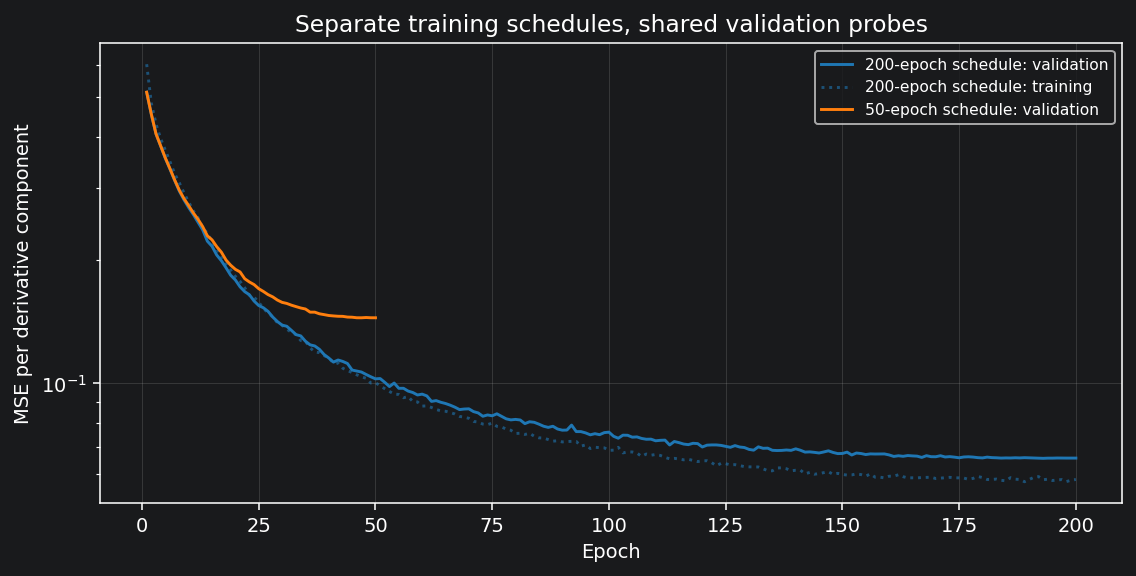

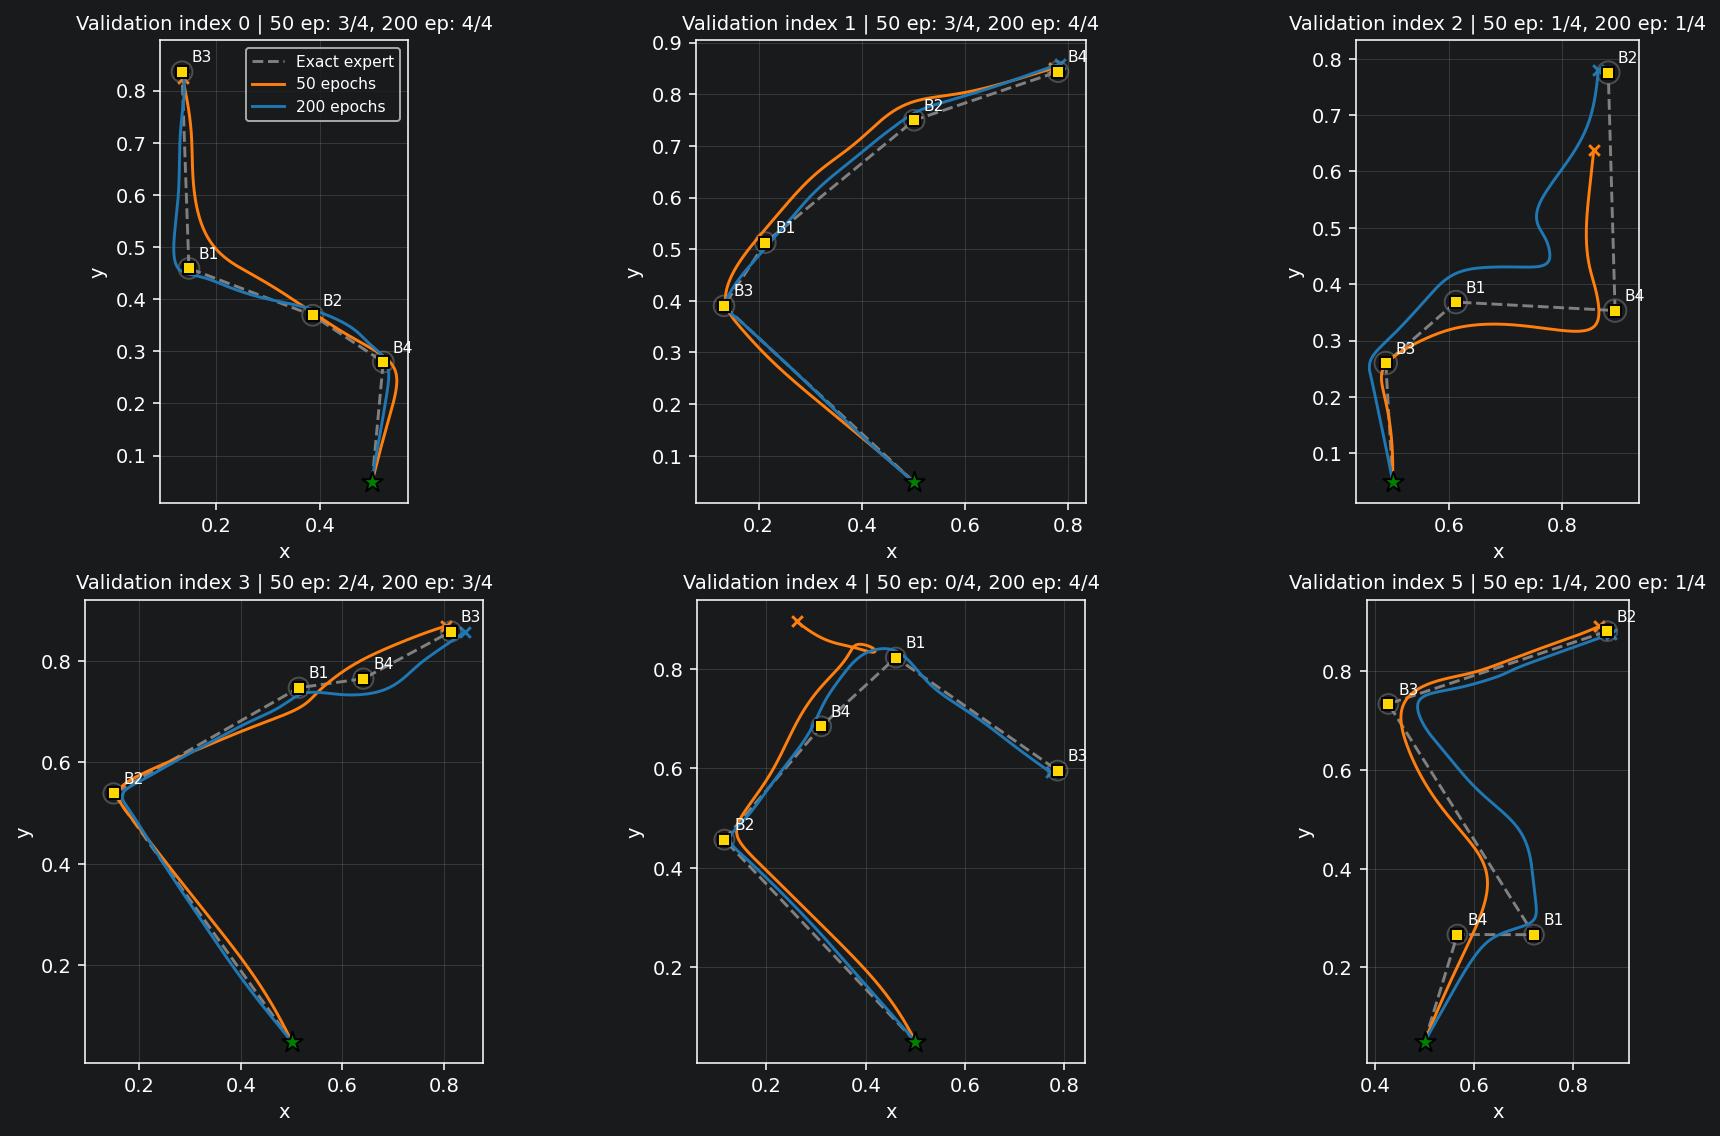

In [7]:
lines = ["| Budget | Layouts | All four visited | Mean visited | Worst-target distance | Expert RMSE | Rollout RMSE |",
         "|---|---|---:|---:|---:|---:|---:|"]
for budget, split_results in results.items():
    for name, r in split_results.items():
        lines.append(f"| {budget} | {name} | {r['all_visited_rate']:.1%} | {r['mean_visited']:.2f}/4 | {r['mean_worst_distance']:.6f} | {r['expert_rmse']:.6f} | {r['rollout_rmse']:.6f} |")
display(Markdown("\n".join(lines)))
for budget, checkpoint in checkpoints.items():
    print(f"{budget}: selected epoch {checkpoint['epoch']}, validation MSE={checkpoint['validation_loss']:.6f}")

fig, ax = plt.subplots(figsize=(8, 4), dpi=140, constrained_layout=True)
ax.plot(np.arange(1, len(history['validation_loss'])+1), history['validation_loss'],
        color='tab:blue', label='200-epoch schedule: validation')
ax.plot(np.arange(1, len(history['train_loss'])+1), history['train_loss'],
        color='tab:blue', linestyle=':', alpha=0.6, label='200-epoch schedule: training')
# The original sorted run stores loss history in latest.pt.
if (BASELINE_DIR / "latest.pt").exists():
    baseline_latest = torch.load(BASELINE_DIR / "latest.pt", map_location="cpu", weights_only=True)
    baseline_history = baseline_latest.get("history", {})
    if "validation_loss" in baseline_history:
        values = baseline_history["validation_loss"]
        ax.plot(np.arange(1, len(values)+1), values, color='tab:orange', label='50-epoch schedule: validation')
    del baseline_latest
ax.set(xlabel='Epoch', ylabel='MSE per derivative component', title='Separate training schedules, shared validation probes')
ax.set_yscale('log')
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
fig.savefig(RUN_DIR / "loss_comparison.png", dpi=180)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(13, 8), dpi=140, constrained_layout=True)
subset = eval_splits['Validation']
for i, ax in enumerate(axes.flat):
    route, targets = subset['routes'][i], subset['targets'][i]
    ax.plot(route[:, 0], route[:, 1], '--', color='gray', label='Exact expert')
    labels = []
    for budget, color in [('50 epochs', 'tab:orange'), ('200 epochs', 'tab:blue')]:
        path = rollout_arrays[(budget, 'Validation')][i]
        ax.plot(path[:, 0], path[:, 1], color=color, label=budget)
        ax.scatter(path[-1, 0], path[-1, 1], color=color, marker='x', s=30)
        count = np.sum(distance_arrays[(budget, 'Validation')][i] <= VISIT_TOLERANCE)
        labels.append(f"{budget.split()[0]} ep: {count}/4")
    ax.scatter(targets[:, 0], targets[:, 1], marker='s', color='gold', edgecolor='black', zorder=5)
    ax.scatter(route[0, 0], route[0, 1], marker='*', s=120, color='green', edgecolor='black', zorder=5)
    for j, target in enumerate(targets):
        ax.add_patch(plt.Circle(target, VISIT_TOLERANCE, fill=False, color='gray', alpha=0.5))
        ax.annotate(f'B{j+1}', target, xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax.set_title(f"Validation index {i} | " + ', '.join(labels), fontsize=10)
    ax.set(xlabel='x', ylabel='y')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.2)
axes[0, 0].legend(fontsize=8)
fig.savefig(RUN_DIR / "fixed_validation_paths.png", dpi=180)
plt.show()


In [8]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

RUN_DIR = Path(
    "/home/matcho/projects/streaming-flow-policy"
    "/experiments/four_boxes_experiments/four_targets"
    "/runs/conditional_mlp_canonical_200epochs_v1_seed0"
)

PRIMARY_TOLERANCE = 0.02

diagnostic_data = {}

for budget in [50, 200]:
    path = RUN_DIR / f"{budget}_epochs_Validation_rollouts.npz"

    with np.load(path, allow_pickle=False) as saved:
        data = {
            key: saved[key].copy()
            for key in saved.files
        }

    distances = data["target_distances"]

    if distances.ndim != 2 or distances.shape[1] != 4:
        raise ValueError("Expected four target distances per layout.")

    if not np.isfinite(distances).all() or np.any(distances < 0):
        raise ValueError("Invalid target distances.")

    data["worst_distance"] = distances.max(axis=1)
    data["visited_count"] = (
        distances <= PRIMARY_TOLERANCE
    ).sum(axis=1)

    diagnostic_data[budget] = data

# Confirm both budgets were evaluated on identical tasks.
np.testing.assert_array_equal(
    diagnostic_data[50]["targets"],
    diagnostic_data[200]["targets"],
)
np.testing.assert_array_equal(
    diagnostic_data[50]["starts"],
    diagnostic_data[200]["starts"],
)

print(
    "Loaded paired validation layouts:",
    len(diagnostic_data[200]["targets"]),
)

Loaded paired validation layouts: 100


In [9]:
diagnostic_thresholds = np.array([
    0.005, 0.01, 0.02, 0.03, 0.05, 0.075, 0.10
])

print(
    f"{'Tolerance':>10} "
    f"{'50 ep: all 4':>15} "
    f"{'200 ep: all 4':>16} "
    f"{'200 ep: mean visits':>22}"
)

for threshold in diagnostic_thresholds:
    old_distances = diagnostic_data[50]["target_distances"]
    new_distances = diagnostic_data[200]["target_distances"]

    old_success = (old_distances <= threshold).all(axis=1).mean()
    new_success = (new_distances <= threshold).all(axis=1).mean()
    new_mean_visits = (
        new_distances <= threshold
    ).sum(axis=1).mean()

    marker = "  <-- primary" if np.isclose(
        threshold, PRIMARY_TOLERANCE
    ) else ""

    print(
        f"{threshold:>10.3f} "
        f"{old_success:>14.1%} "
        f"{new_success:>15.1%} "
        f"{new_mean_visits:>19.2f}/4"
        f"{marker}"
    )

worst_200 = diagnostic_data[200]["worst_distance"]
counts_200 = diagnostic_data[200]["visited_count"]

print("\n200-epoch worst-target distance quantiles:")
for quantile in [0.25, 0.50, 0.75, 0.90, 0.95, 1.00]:
    print(
        f"  Q{100 * quantile:05.1f}: "
        f"{np.quantile(worst_200, quantile):.6f}"
    )

print("\n200-epoch target counts at tolerance 0.02:")
for count in range(5):
    print(
        f"  Visited {count}/4:",
        int(np.sum(counts_200 == count)),
    )

groups = {
    "All targets within 0.02": worst_200 <= 0.02,
    "Worst target in (0.02, 0.05]": (
        (worst_200 > 0.02) & (worst_200 <= 0.05)
    ),
    "Worst target farther than 0.05": worst_200 > 0.05,
}

print("\nDescriptive distance groups:")
for name, mask in groups.items():
    print(f"  {name}: {mask.sum()} / {len(mask)}")

# Paired comparison: do not rely only on aggregate success rates.
old_success = (
    diagnostic_data[50]["worst_distance"] <= PRIMARY_TOLERANCE
)
new_success = worst_200 <= PRIMARY_TOLERANCE

print("\nPaired completion changes at tolerance 0.02:")
print("  Success at both budgets:", int((old_success & new_success).sum()))
print("  Became successful:", int((~old_success & new_success).sum()))
print("  Lost success:", int((old_success & ~new_success).sum()))
print("  Failed at both budgets:", int((~old_success & ~new_success).sum()))

distance_change = (
    worst_200 - diagnostic_data[50]["worst_distance"]
)
print(
    "  Median change in worst-target distance (200 - 50):",
    f"{np.median(distance_change):.6f}",
)

 Tolerance    50 ep: all 4    200 ep: all 4    200 ep: mean visits
     0.005           0.0%            1.0%                0.68/4
     0.010           0.0%            5.0%                1.39/4
     0.020           5.0%           21.0%                2.28/4  <-- primary
     0.030           7.0%           37.0%                2.80/4
     0.050          22.0%           53.0%                3.27/4
     0.075          35.0%           66.0%                3.47/4
     0.100          46.0%           74.0%                3.62/4

200-epoch worst-target distance quantiles:
  Q025.0: 0.022431
  Q050.0: 0.047850
  Q075.0: 0.103695
  Q090.0: 0.227682
  Q095.0: 0.296794
  Q100.0: 0.391517

200-epoch target counts at tolerance 0.02:
  Visited 0/4: 4
  Visited 1/4: 28
  Visited 2/4: 25
  Visited 3/4: 22
  Visited 4/4: 21

Descriptive distance groups:
  All targets within 0.02: 21 / 100
  Worst target in (0.02, 0.05]: 32 / 100
  Worst target farther than 0.05: 47 / 100

Paired completion changes at t

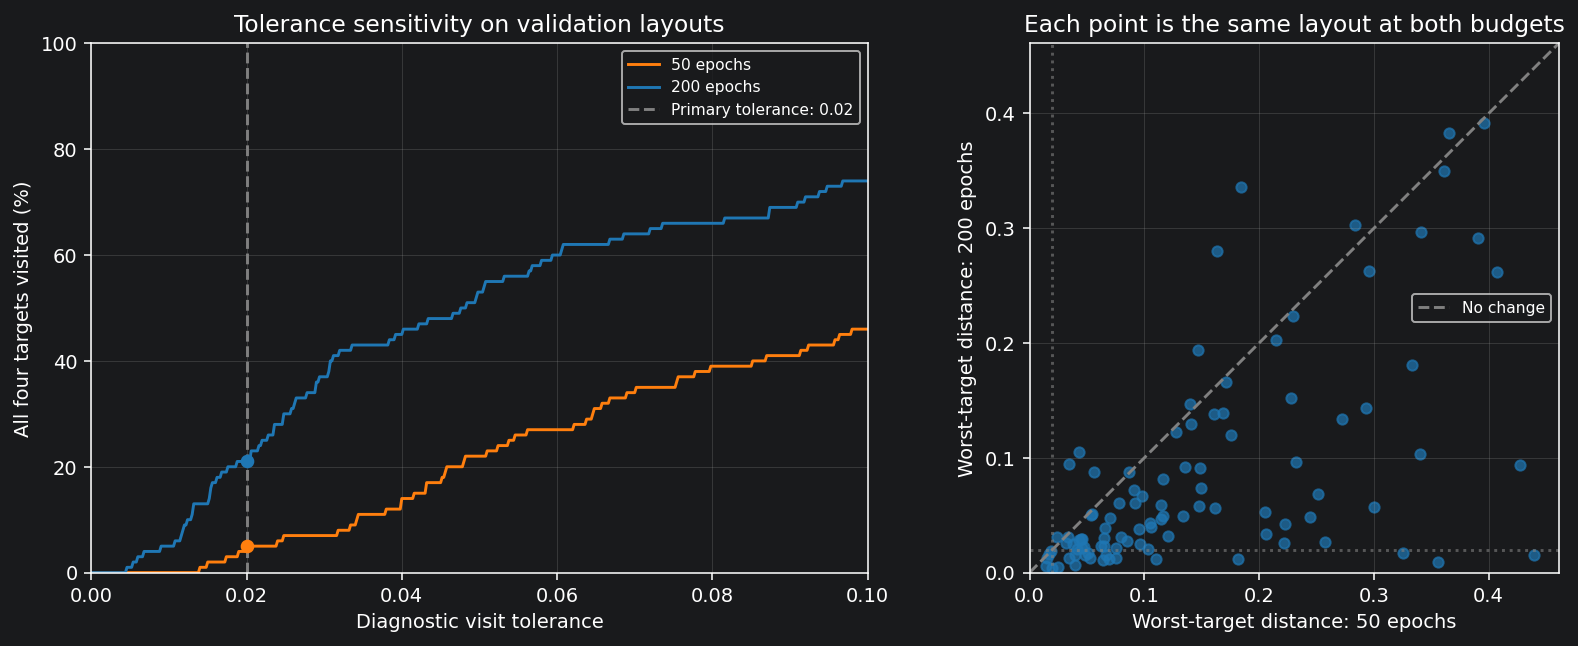

Saved: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/conditional_mlp_canonical_200epochs_v1_seed0/validation_tolerance_diagnostics.png


In [10]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    dpi=140,
    constrained_layout=True,
)

curve_thresholds = np.linspace(0.0, 0.10, 501)

for budget, color in [(50, "tab:orange"), (200, "tab:blue")]:
    worst = diagnostic_data[budget]["worst_distance"]

    success_curve = (
        worst[:, None] <= curve_thresholds[None, :]
    ).mean(axis=0)

    axes[0].plot(
        curve_thresholds,
        100 * success_curve,
        color=color,
        label=f"{budget} epochs",
    )

    axes[0].scatter(
        [PRIMARY_TOLERANCE],
        [100 * np.mean(worst <= PRIMARY_TOLERANCE)],
        color=color,
        zorder=4,
    )

axes[0].axvline(
    PRIMARY_TOLERANCE,
    color="gray",
    linestyle="--",
    label="Primary tolerance: 0.02",
)
axes[0].set(
    xlabel="Diagnostic visit tolerance",
    ylabel="All four targets visited (%)",
    title="Tolerance sensitivity on validation layouts",
    xlim=(0, 0.10),
    ylim=(0, 100),
)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

old_worst = diagnostic_data[50]["worst_distance"]
new_worst = diagnostic_data[200]["worst_distance"]

upper = max(old_worst.max(), new_worst.max(), 0.02) * 1.05

axes[1].scatter(
    old_worst,
    new_worst,
    s=28,
    alpha=0.7,
    color="tab:blue",
)
axes[1].plot(
    [0, upper], [0, upper],
    "--", color="gray", label="No change",
)
axes[1].axhline(
    PRIMARY_TOLERANCE,
    color="gray", linestyle=":", alpha=0.6,
)
axes[1].axvline(
    PRIMARY_TOLERANCE,
    color="gray", linestyle=":", alpha=0.6,
)
axes[1].set(
    xlabel="Worst-target distance: 50 epochs",
    ylabel="Worst-target distance: 200 epochs",
    title="Each point is the same layout at both budgets",
    xlim=(0, upper),
    ylim=(0, upper),
)
axes[1].set_aspect("equal", adjustable="box")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

figure_path = RUN_DIR / "validation_tolerance_diagnostics.png"
fig.savefig(figure_path, dpi=180)
plt.show()

summary = {
    "primary_tolerance": PRIMARY_TOLERANCE,
    "num_validation_layouts": len(worst_200),
    "threshold_results": [
        {
            "tolerance": float(threshold),
            "success_50": float(np.mean(old_worst <= threshold)),
            "success_200": float(np.mean(new_worst <= threshold)),
        }
        for threshold in diagnostic_thresholds
    ],
    "groups_200": {
        name: int(mask.sum())
        for name, mask in groups.items()
    },
    "paired_completion": {
        "success_both": int((old_success & new_success).sum()),
        "became_successful": int((~old_success & new_success).sum()),
        "lost_success": int((old_success & ~new_success).sum()),
        "failed_both": int((~old_success & ~new_success).sum()),
    },
}

(RUN_DIR / "validation_tolerance_diagnostics.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

print("Saved:", figure_path)